# 02 · Surface context: the RF20 PRE-event surface classification

Context layer of Paper 3: evaluation strata for the U-Net arms and the classes of the disagreement ontology. Reference = ESA WorldCover 2021, the training reference — these are *agreement* numbers, not validation.

**Reading rules.** Every model number is *agreement with weak reference labels*, never flood-mapping accuracy. "Not observed is not dry." Areas carry their semantics (observed_S1 / mapped_UNet / terrain_reconstructed / literature_reported). Evidence levels: independent_physical › cross_sensor › weak_label_agreement › contextual.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "case_studies/kakhovka_2023/tables").exists())
CS = ROOT / "case_studies/kakhovka_2023"; T = CS / "tables"; PT = CS / "publication/tables"; PF = CS / "publication/figures"; RUNS = CS / "runs"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
C = {"terrain": "#2a78d6", "s1": "#eb6834", "unet": "#4a3aa7", "rf": "#1baf7a", "gauge": "#52514e"}
def show(tid, n=None):
    df = pd.read_csv(PT / f"{tid}.csv"); cap = json.loads((PT / "manifest.json").read_text())["tables"][tid]
    display(Markdown(f"**{tid}** [{cap['evidence_level']}] {cap['caption']}")); return df.head(n) if n else df
def fig(name): p = next(PF.glob(name + "*.png"), None); display(Image(str(p), width=900)) if p else print("figure not rendered yet:", name)
print("repo:", ROOT)

repo: /home/niko/repo/floodstate-eo


## 1. Per-class agreement (spatial-block 5-fold CV and frame transfers)

In [2]:
show('T09')

**T09** [contextual] RF20 surface classification: per-class precision / recall / F1 with support, macro means (over the classes) and overall agreement, spatial-block 5-fold CV (rev 2 also with a 3.5 km buffer around the test blocks) and frame transfers (rev 2: outside the B1/B2 overlap). Reference = WorldCover 2021, the training reference. Rev 2 is the product in use (review F08); rev 1 rows are the superseded model.

,rev,evaluation,cls,precision,recall,F1,n,train_kept_share_per_fold,OA_spatial_cv,kappa_spatial_cv_csv_only,status,reference
0,2,spatial_block_cv_5fold,WATER,0.9977,0.9984,0.9981,60000,NaN,0.9381,0.9274,"in use (review F08: global UTM blocks, B1/B2 o...",ESA WorldCover 2021 (training reference; agree...
1,2,spatial_block_cv_5fold,CROPLAND,0.9187,0.9247,0.9217,60000,NaN,0.9381,0.9274,"in use (review F08: global UTM blocks, B1/B2 o...",ESA WorldCover 2021 (training reference; agree...
2,2,spatial_block_cv_5fold,GRASS_LOW_VEGETATION,0.8679,0.8730,0.8704,60000,NaN,0.9381,0.9274,"in use (review F08: global UTM blocks, B1/B2 o...",ESA WorldCover 2021 (training reference; agree...
3,2,spatial_block_cv_5fold,FOREST,0.9303,0.9300,0.9301,60000,NaN,0.9381,0.9274,"in use (review F08: global UTM blocks, B1/B2 o...",ESA WorldCover 2021 (training reference; agree...
4,2,spatial_block_cv_5fold,WETLAND_REED,0.9663,0.9280,0.9467,60000,NaN,0.9381,0.9274,"in use (review F08: global UTM blocks, B1/B2 o...",ESA WorldCover 2021 (training reference; agree...
...,...,...,...,...,...,...,...,...,...,...,...,...
65,1,transfer_B2_to_B1,MACRO,0.9341,0.9326,0.9319,210000,NaN,NaN,NaN,"superseded (frame-local block ids, the B1/B2 o...",ESA WorldCover 2021 (training reference; agree...
66,1,transfer_B2_to_B1,OVERALL_ACCURACY,NaN,NaN,0.9326,210000,NaN,NaN,NaN,"superseded (frame-local block ids, the B1/B2 o...",ESA WorldCover 2021 (training reference; agree...
67,1,spatial_block_cv_5fold,MACRO_MEAN,0.9445,0.9418,0.9430,392420,NaN,0.9404,0.9301,"superseded (frame-local block ids, the B1/B2 o...",ESA WorldCover 2021 (training reference; agree...
68,1,transfer_B1_to_B2,MACRO_MEAN,0.9319,0.8866,0.9038,182420,NaN,NaN,NaN,"superseded (frame-local block ids, the B1/B2 o...",ESA WorldCover 2021 (training reference; agree...


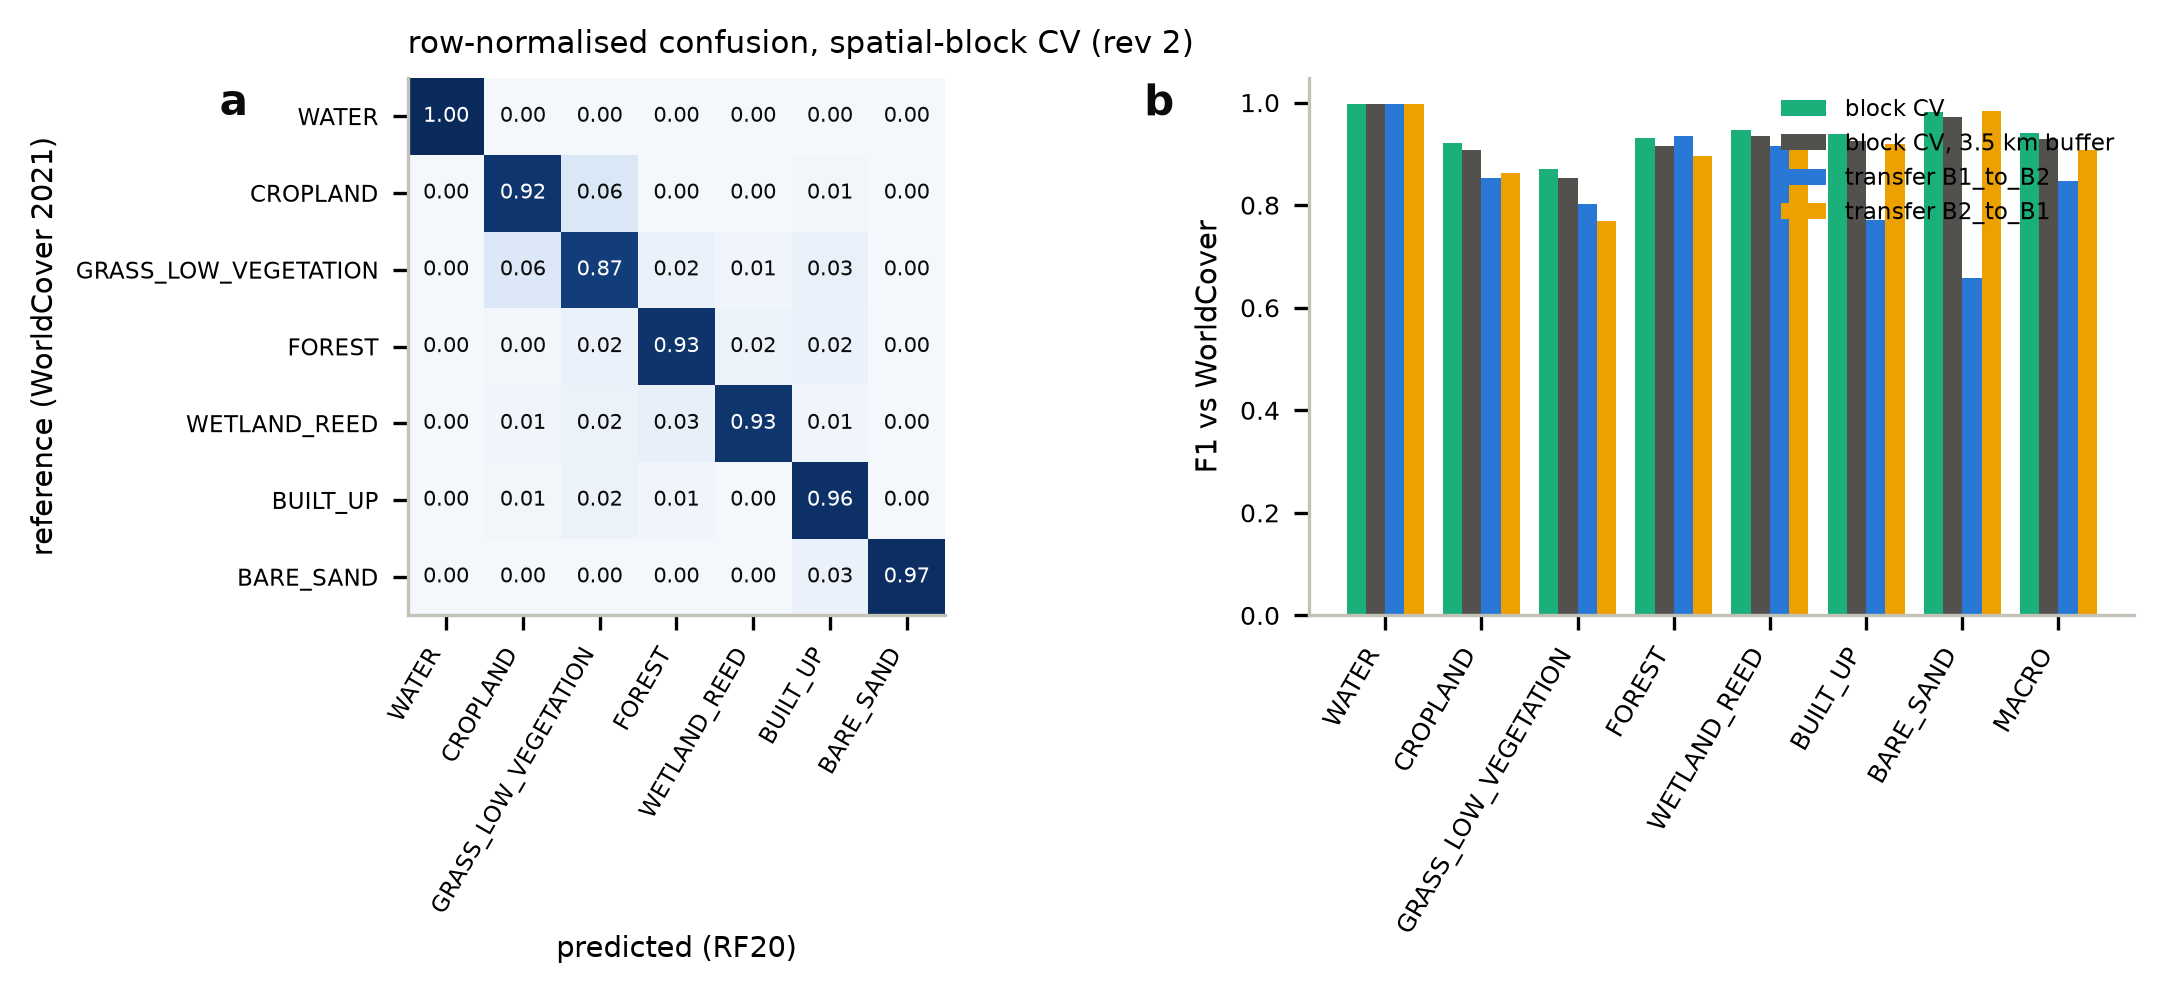

In [3]:
fig('FigS04')

## 2. Confusion matrix and class areas

In [4]:
show('T10'); show('T10b')

**T10** [contextual] RF20 confusion matrix (spatial-block CV, counts; rev 2).

**T10b** [contextual] RF20 class areas per frame, km2 (mapped areas of a context product; rev 2).

,frame,p73_class,km2,share_pct
0,B1,WATER,156.01,2.56
1,B1,CROPLAND,3292.67,54.05
2,B1,GRASS_LOW_VEGETATION,1057.16,17.35
3,B1,FOREST,541.38,8.89
4,B1,SHRUB,0.00,0.00
5,B1,WETLAND_REED,297.45,4.88
6,B1,BUILT_UP,285.42,4.69
7,B1,BARE_SAND,117.75,1.93
8,B1,OTHER,0.00,0.00
9,B1,UNCERTAIN,343.85,5.64


## 3. Wall-to-wall agreement with WorldCover (crosswalk, not validation)

In [5]:
show('T10c')

**T10c** [contextual] RF20 vs WorldCover wall-to-wall agreement on WorldCover-pure cells (recall / precision vs the training reference; rev 2).

,frame,p73_class,worldcover,wc_pure_km2,recall_vs_wc,precision_vs_wc
0,B1,WATER,water,173.5,0.8840,0.9958
1,B1,CROPLAND,cropland,3397.2,0.9301,0.9879
2,B1,GRASS_LOW_VEGETATION,grass,918.4,0.8034,0.8508
3,B1,FOREST,tree,448.8,0.9229,0.9497
4,B1,SHRUB,shrub,0.0,0.0000,0.0000
5,B1,WETLAND_REED,herb_wetland,239.5,0.9360,0.9200
6,B1,BUILT_UP,built,140.8,0.9493,0.8034
7,B1,BARE_SAND,bare,27.2,0.9925,0.3863
8,B1,OTHER,snow,0.0,0.0000,0.0000
9,B1,OTHER,mangrove,0.0,0.0000,0.0000


## 4. QA verdict and known limitations (p73 freeze)
Rev 2 (review F08: global blocks, the B1/B2 overlap owned by B2 before sampling, buffered CV) is the product in use once built; rev 1 is the superseded model.

In [6]:
QA = T / ('p73_rf20_rev2_qa' if (T / 'p73_rf20_rev2_qa').exists() else 'p73_rf20_qa'); print(QA.name)
v = QA / 'QA_VERDICT.md'; print(v.read_text()[:6000] if v.exists() else 'no verdict file in ' + QA.name)

p73_rf20_rev2_qa
# p73 RF20 rev 2 — QA verdict: PASS → P73_RF20_REV2_FROZEN (2026-09-29; clean-tree reproducibility gate PASS)

Rev 2 answers review F08 (2026-09-28): 5 km blocks from the UTM coordinates of the 20 m cells (one physical cell, one block,
in both frames); B2 owns the B1/B2 overlap and B1 contributes no target there (3 093 025 B1 target cells dropped), so a
physical cell enters the sample once (asserted); the CV is reported without and with a 3.5 km buffer around the test blocks;
the frame transfers train and test outside the overlap only. Rev 1 (`../p73_rf20_qa/`, frozen 2026-09-23) is superseded.

Run: `p73_rf20_surface.py --rev 2 --jobs 12` on 2026-09-29 (15 min, 9.6 GB peak); the p73 code and every module it imports
are identical to commit 214bf93 (the working tree had uncommitted edits in other files); model sha256 in
`../p73_rf20_rev2_manifest.json`.

## Reproducibility gate — PASS
The clean-worktree re-run at `acf190c` (`dirty_tracked: false`, 14 min, 10.2 GB) repro

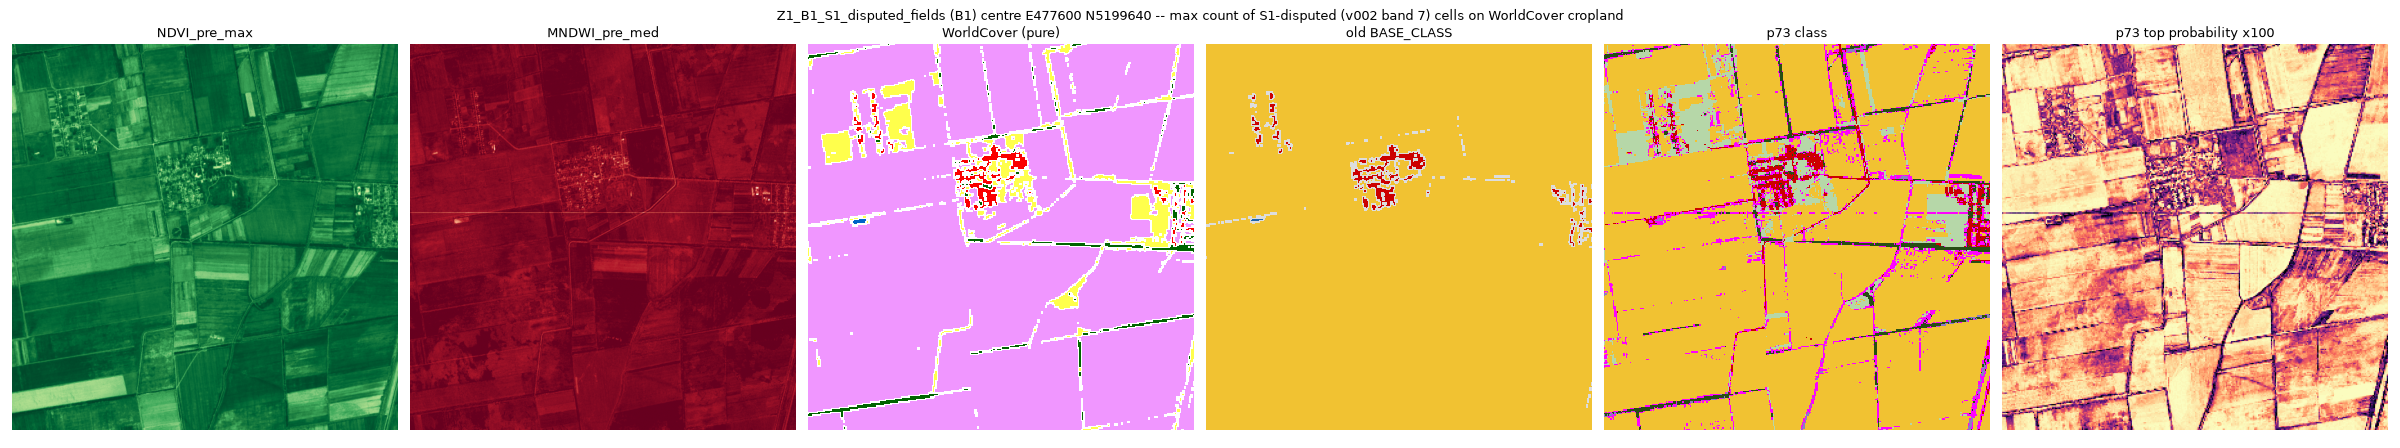

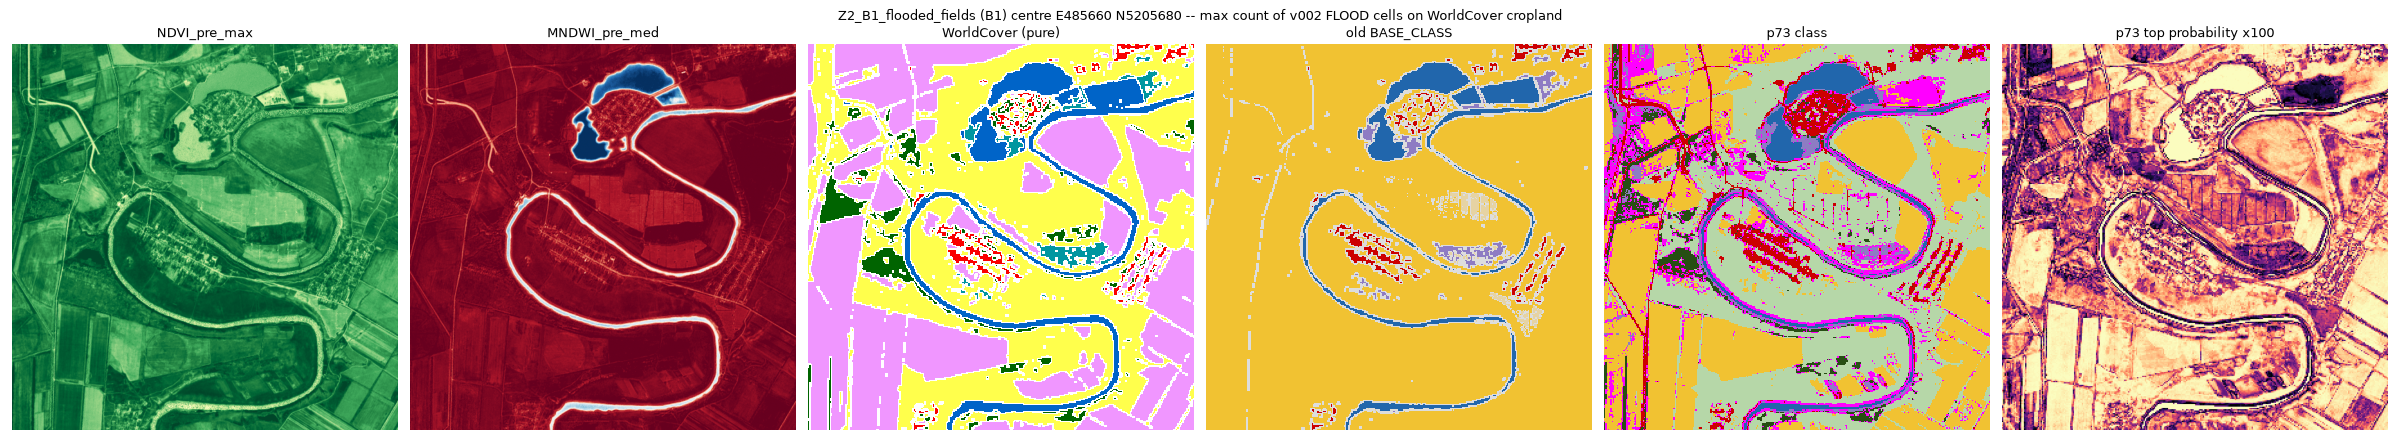

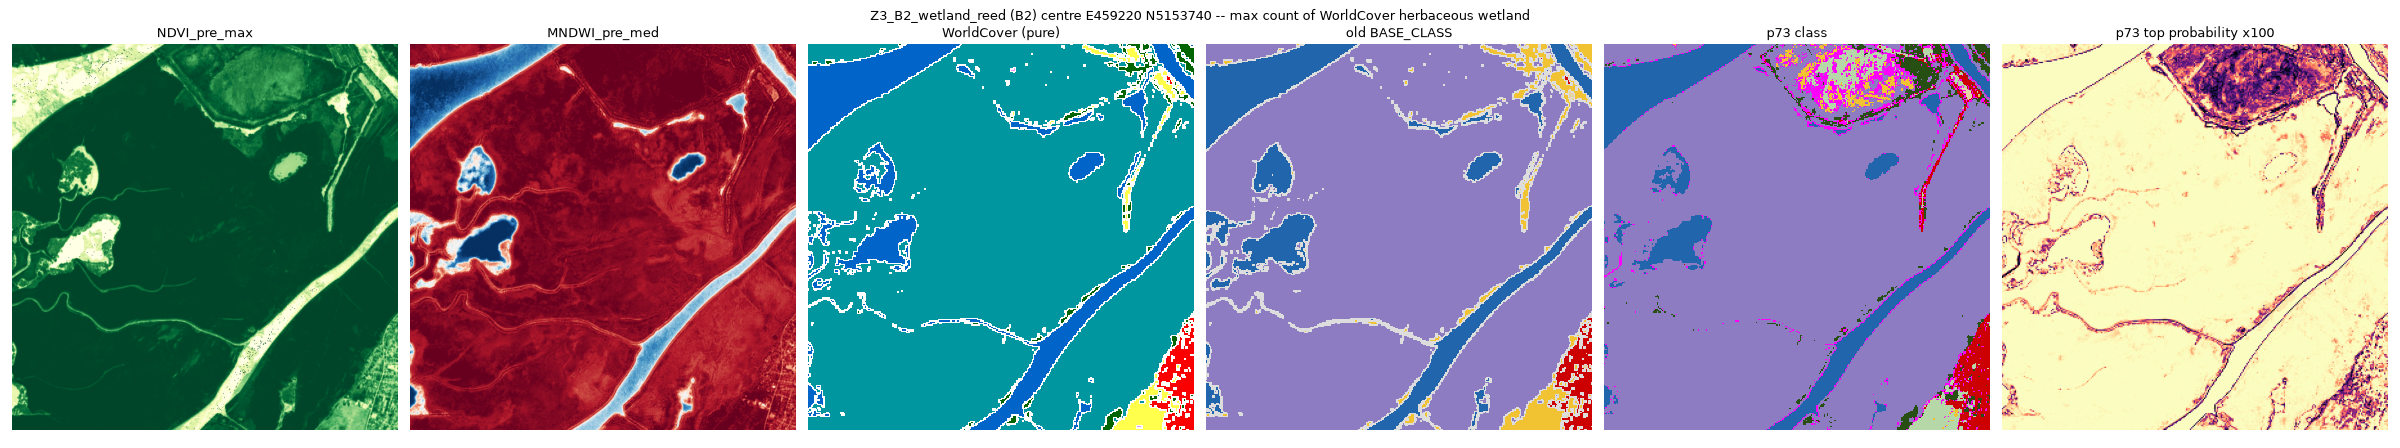

In [7]:
for p in sorted(QA.glob('Z*.png'))[:3]: display(Image(str(p), width=800))